In [6]:
"""
simulation_info.py

A class to store and inter-convert resolution and volume information
for cosmological simulations, enabling apples-to-apples comparisons
between different flagship runs.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ---------------------------------------------------------------------------
# Default cosmology (Planck 2018-ish)
# ---------------------------------------------------------------------------
DEFAULT_COSMO = dict(
    h       = 0.6774,
    Omega_b = 0.0486,
    Omega_dm= 0.2589,
    # Omega_m is derived
    rho_crit_cgs = 1.8788e-29,  # h^2 g/cm^3  (i.e. rho_crit = rho_crit_cgs * h^2)
)
DEFAULT_COSMO["Omega_m"] = DEFAULT_COSMO["Omega_b"] + DEFAULT_COSMO["Omega_dm"]

# ---------------------------------------------------------------------------
# Unit conversion constants
# ---------------------------------------------------------------------------
MSUN_CGS   = 1.989e33        # g
MPC_CGS    = 3.0857e24       # cm
KPC_CGS    = MPC_CGS * 1e-3  # cm


class SimulationInfo:
    """
    Store and inter-convert two fundamental simulation properties:

      1. Resolution  -- either a baryonic particle mass (Msun) or a
         comoving spatial cell size (kpc, with optional /h).
      2. Volume      -- either a box side-length, a box volume, or a
         halo mass (zoom simulations).

    Parameters
    ----------
    name : str
        Human-readable label (e.g. "IllustrisTNG-300").

    resolution : tuple  (value, kind)
        value : float or str   -- numeric resolution value
        kind  : str            -- one of
            'particle'   ->  value is baryonic particle mass in Msun
            'kpccm/h'    ->  comoving spatial resolution in kpc/h
            'kpccm'      ->  comoving spatial resolution in kpc

    volume : tuple  (tag, value, unit)
        tag   : str   -- 'V' (volume), 'S' (side-length), or 'H' (halo)
        value : float -- numeric value
        unit  : str   -- for V/S: 'Mpccm/h' or 'Mpccm'
                         for H: 'M_dm', 'M_b', or 'M_tot'  (Msun implied)

    ref_density_cgs : float
        Reference *physical* density in g/cm^3 at redshift ref_redshift,
        used to convert between particle mass and spatial resolution.

    ref_redshift : float
        Redshift at which ref_density_cgs is defined.  The conversion is:
            dx_phys = (m / rho_ref)^{1/3}
            dx_comoving = dx_phys * (1 + ref_redshift)
        Default is 0.

    cosmo : dict, optional
        Cosmological parameters; defaults to Planck 2018.
    """

    def __init__(self, name, resolution, volume, ref_density_cgs,
                 ref_redshift=4.0, cosmo=None):
        self.name = name
        self.cosmo = cosmo if cosmo is not None else dict(DEFAULT_COSMO)

        # Store the raw input tuples so we know what was specified
        self._resolution_input = resolution
        self._volume_input     = volume

        # Classify the input types for marker styling
        #   res_type:  'particle' or 'spatial'
        #   vol_type:  'box' or 'halo'
        res_kind = resolution[1]
        self.res_type = "particle" if res_kind == "particle" else "spatial"
        self.vol_type = "halo" if volume[0] == "H" else "box"

        # Compute everything from the raw inputs + reference density
        self.ref_density_cgs = ref_density_cgs
        self.ref_redshift    = ref_redshift
        self._compute(resolution, volume)

    # -------------------------------------------------------------------
    #  Core computation (called on init and when ref_density changes)
    # -------------------------------------------------------------------
    def _compute(self, resolution, volume):
        h  = self.cosmo["h"]
        Ob = self.cosmo["Omega_b"]
        Od = self.cosmo["Omega_dm"]
        Om = self.cosmo["Omega_m"]
        rho_crit = self.cosmo["rho_crit_cgs"] * h**2  # g/cm^3

        # ---------------------------------------------------------------
        # 1.  RESOLUTION  ->  particle mass (Msun)  +  spatial res (kpccm)
        #
        #  ref_density_cgs is a *physical* density at z = ref_redshift.
        #  A cell of physical size dx_phys has mass  m = rho_ref * dx_phys^3.
        #  The comoving size is  dx_cm = dx_phys * (1+z).
        # ---------------------------------------------------------------
        res_val  = float(resolution[0])
        res_kind = resolution[1]
        oneplusz = 1.0 + self.ref_redshift

        if res_kind == "particle":
            self.m_baryon_msun = res_val
            m_cgs = res_val * MSUN_CGS
            # dx_phys = (m / rho_ref)^{1/3}
            dx_phys_cm = (m_cgs / self.ref_density_cgs) ** (1.0 / 3.0)
            # dx_comoving = dx_phys * (1+z)
            self.dx_kpccm = dx_phys_cm * oneplusz / KPC_CGS

        elif res_kind == "kpccm/h":
            dx_kpc_cm = res_val / h
            self.dx_kpccm = dx_kpc_cm
            # dx_phys = dx_comoving / (1+z)
            dx_phys_cm = dx_kpc_cm * KPC_CGS / oneplusz
            m_cgs = self.ref_density_cgs * dx_phys_cm**3
            self.m_baryon_msun = m_cgs / MSUN_CGS

        elif res_kind == "kpccm":
            self.dx_kpccm = res_val
            dx_phys_cm = res_val * KPC_CGS / oneplusz
            m_cgs = self.ref_density_cgs * dx_phys_cm**3
            self.m_baryon_msun = m_cgs / MSUN_CGS

        else:
            raise ValueError(f"Unknown resolution kind: {res_kind!r}")

        # ---------------------------------------------------------------
        # 2.  VOLUME  ->  comoving volume in Mpc^3
        # ---------------------------------------------------------------
        tag    = volume[0]
        v_val  = float(volume[1])
        v_unit = volume[2]

        if tag == "V":
            if v_unit == "Mpccm/h":
                self.volume_mpc3 = v_val / h**3
            elif v_unit == "Mpccm":
                self.volume_mpc3 = v_val
            else:
                raise ValueError(f"Unknown volume unit: {v_unit!r}")

        elif tag == "S":
            if v_unit == "Mpccm/h":
                side_mpc = v_val / h
            elif v_unit == "Mpccm":
                side_mpc = v_val
            else:
                raise ValueError(f"Unknown side-length unit: {v_unit!r}")
            self.volume_mpc3 = side_mpc**3

        elif tag == "H":
            m_halo_cgs = v_val * MSUN_CGS
            if v_unit == "M_dm":
                rho_mean_cgs = rho_crit * Od
            elif v_unit == "M_b":
                rho_mean_cgs = rho_crit * Ob
            elif v_unit == "M_tot":
                rho_mean_cgs = rho_crit * Om
            else:
                raise ValueError(f"Unknown halo mass type: {v_unit!r}")
            vol_cm3 = m_halo_cgs / rho_mean_cgs
            self.volume_mpc3 = vol_cm3 / MPC_CGS**3

        else:
            raise ValueError(f"Unknown volume tag: {tag!r}")

        # Derived convenience quantities
        self.side_mpc = self.volume_mpc3 ** (1.0 / 3.0)

    # -------------------------------------------------------------------
    #  Change reference density and recompute derived resolution
    # -------------------------------------------------------------------
    def set_ref_density(self, ref_density_cgs, ref_redshift=None):
        """
        Update the reference density (g/cm^3) and optionally the
        reference redshift, then recompute the particle-mass <->
        spatial-resolution mapping.

        The volume side is *not* affected by reference density.
        """
        self.ref_density_cgs = ref_density_cgs
        if ref_redshift is not None:
            self.ref_redshift = ref_redshift
        self._compute(self._resolution_input, self._volume_input)

    # -------------------------------------------------------------------
    # Pretty printing
    # -------------------------------------------------------------------
    def __repr__(self):
        return (
            f"SimulationInfo('{self.name}')\n"
            f"  m_baryon     = {self.m_baryon_msun:.3e} Msun\n"
            f"  dx           = {self.dx_kpccm:.3f} kpccm\n"
            f"  Volume       = {self.volume_mpc3:.3e} Mpc^3\n"
            f"  Side-length  = {self.side_mpc:.2f} Mpc\n"
            f"  ref_density  = {self.ref_density_cgs:.2e} g/cm^3 @ z={self.ref_redshift}"
        )

    def summary_dict(self):
        """Return a dict handy for tabulation / plotting."""
        return dict(
            name          = self.name,
            m_baryon_msun = self.m_baryon_msun,
            dx_kpccm      = self.dx_kpccm,
            volume_mpc3   = self.volume_mpc3,
            side_mpc      = self.side_mpc,
            res_type      = self.res_type,
            vol_type      = self.vol_type,
        )


# =======================================================================
#  Marker style map for the 4 input-type categories
# =======================================================================
_MARKER_STYLES = {
    # (res_type, vol_type) : (marker, label)
    ("particle", "box")  : ("o",  "particle + box"),
    ("particle", "halo") : ("*",  "particle + halo (zoom)"),
    ("spatial",  "box")  : ("s",  "spatial + box"),
    ("spatial",  "halo") : ("D",  "spatial + halo (zoom)"),
}


# =======================================================================
#  Plotting function
# =======================================================================
def plot_simulation_comparison(sims, ref_density_cgs=None, ref_redshift=None,
                                savefig=None, figsize=(14, 6),
                                xlim=None, ylim_dx=None, ylim_mass=None):
    """
    Scatter-plot a list of SimulationInfo objects on two panels:

        Left  :  box side-length  vs  dx  (comoving kpc)
        Right :  box side-length  vs  m_baryon  (Msun)

    Both axes are log-scale.  An upper x-axis shows box volume.

    Grey reference lines on the mass panel show iso-N_total curves.
    N_total = 2 * N_baryon (equal baryon + DM counts assumed), so
    m_baryon = 2 * rho_bar_mean * L^3 / N_total.

    Parameters
    ----------
    sims : list of SimulationInfo
    ref_density_cgs : float, optional
        If given, every sim's reference density is temporarily set to
        this value before plotting so the comparison is self-consistent.
        Original densities are restored afterwards.
    ref_redshift : float, optional
        If given (alongside ref_density_cgs), the reference redshift is
        also overridden for all sims.
    savefig : str or None
        Path to save the figure (e.g. 'comparison.png').
    figsize : tuple
    xlim : tuple or None
        (xmin, xmax) for box side-length axis (Mpc), shared by both panels.
    ylim_dx : tuple or None
        (ymin, ymax) for the dx panel (kpccm).
    ylim_mass : tuple or None
        (ymin, ymax) for the baryon mass panel (Msun).
    """
    # --- optionally override reference densities -----------------------
    old_densities = None
    if ref_density_cgs is not None:
        old_densities = [(s.ref_density_cgs, s.ref_redshift) for s in sims]
        for s in sims:
            s.set_ref_density(ref_density_cgs, ref_redshift=ref_redshift)
    # use whatever density is current (either overridden or original)
    active_density = sims[0].ref_density_cgs if sims else ref_density_cgs

    # --- gather data ---------------------------------------------------
    sides    = np.array([s.side_mpc for s in sims])
    volumes  = np.array([s.volume_mpc3 for s in sims])
    dx_arr   = np.array([s.dx_kpccm for s in sims])
    mass_arr = np.array([s.m_baryon_msun for s in sims])
    names    = [s.name for s in sims]
    cats     = [(s.res_type, s.vol_type) for s in sims]

    # --- figure --------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize,
                                   sharex=True)

    # ===================================================================
    #  Reference iso-N_total lines  (mass panel only)
    #
    #  N_total = 2 * N_baryon  (equal baryon + DM particle counts).
    #  m_baryon = rho_bar_mean * L^3 / N_baryon
    #           = 2 * rho_bar_mean * L^3 / N_total
    #
    #  Lines always use the cosmic mean baryon density, since particle
    #  masses are physical and independent of the reference density
    #  chosen for the dx <-> m conversion.
    # ===================================================================
    cosmo = sims[0].cosmo if sims else DEFAULT_COSMO
    rho_bar_mean = cosmo["rho_crit_cgs"] * cosmo["h"]**2 * cosmo["Omega_b"]

    L_range = np.logspace(np.log10(0.5), np.log10(3000), 200)  # Mpc

    for n_per_side in [256, 512, 1024, 2048, 4096]:
        N_total = n_per_side**3

        # m_baryon = 2 * rho_bar_mean * L^3 / N_total
        L_cm   = L_range * MPC_CGS
        m_line = 2.0 * rho_bar_mean * L_cm**3 / N_total / MSUN_CGS

        i = np.where(m_line < 5e8)
        #ax2.plot(L_range[i], m_line[i], color="0.80", lw=0.7, ls=":", zorder=0)

    # ===================================================================
    #  Scatter points  (4 categories)
    # ===================================================================
    plotted_labels = set()
    for i, s in enumerate(sims):
        cat = cats[i]
        marker, cat_label = _MARKER_STYLES[cat]
        # only add legend entry once per category
        lbl = cat_label if cat_label not in plotted_labels else None
        plotted_labels.add(cat_label)

        kw = dict(marker=marker, s=80, edgecolors="k", linewidths=0.6,
                  zorder=5, label=lbl)
        ax1.scatter(sides[i], dx_arr[i],   **kw)
        ax2.scatter(sides[i], mass_arr[i], **kw)

        # annotate with name
        for ax, yval in [(ax1, dx_arr[i]), (ax2, mass_arr[i])]:
            ax.annotate(names[i], (sides[i], yval),
                        textcoords="offset points", xytext=(5, 5),
                        fontsize=7, zorder=6)

    # ===================================================================
    #  Axes formatting
    # ===================================================================
    for ax in (ax1, ax2):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Box side-length  [Mpc comoving]")
        ax.legend(fontsize=8, loc="upper right", framealpha=0.9)
        #ax.grid(True, which="both", ls=":", lw=0.4, alpha=0.4)

        # --- upper x-axis: volume ---
        ax_top = ax.secondary_xaxis("top",
                                    functions=(lambda x: x**3,
                                               lambda v: v**(1./3.)))
        ax_top.set_xlabel("Box volume  [Mpc$^3$ comoving]")
        ax_top.set_xscale("log")

    ax1.set_ylabel(r"$\Delta x$  [kpccm]")
    ax2.set_ylabel(r"$m_{\rm baryon}$  [$M_\odot$]")

    ax1.invert_yaxis()
    ax2.invert_yaxis()

    # --- optional axis limits ------------------------------------------
    if xlim is not None:
        ax1.set_xlim(xlim)
        ax2.set_xlim(xlim)
    if ylim_dx is not None:
        ax1.set_ylim(ylim_dx)
    # Default mass limits: 1e9 (bottom) to 1e2 (top) since axis is inverted
    mass_lim = ylim_mass if ylim_mass is not None else (1e9, 1e2)
    ax2.set_ylim(mass_lim)

    # --- iso-N line labels (placed after axis limits are finalised) -----
    # Anchor each label where its line crosses the bottom of the plot
    # (the large-mass edge).  With inverted axis, mass_lim[0] is the
    # bottom (large mass) value.
    m_bottom = mass_lim[0]  # Msun
    for n_per_side in [256, 512, 1024, 2048, 4096]:
        N_total = n_per_side**3
        # Solve for L where m_baryon = m_bottom:
        #   m_bottom = 2 * rho_bar * L^3 / N  =>  L = (m*N/(2*rho_bar))^{1/3}
        L_anchor_cm = (m_bottom * MSUN_CGS * N_total
                       / (2.0 * rho_bar_mean))**(1.0/3.0)
        L_anchor_mpc = L_anchor_cm / MPC_CGS
        label_str = f"${n_per_side}^3$"
        ax2.annotate(label_str,
                     xy=(L_anchor_mpc*0.9, m_bottom/2),
                     fontsize=7, color="0.50", va="top", ha="center",
                     annotation_clip=True)

    # --- reference density annotation ----------------------------------
    active_z = sims[0].ref_redshift if sims else 0.0
    rho_comoving = active_density / (1.0 + active_z)**3
    rho_str = (f"ref density = {active_density:.2e} g/cm$^3$ @ $z={active_z:.1f}$"
               f"    (comoving equiv. = {rho_comoving:.2e} g/cm$^3$)")
    fig.text(0.5, 0.01, rho_str, ha="center", fontsize=9,
             fontstyle="italic", color="0.35")

    fig.suptitle("Simulation Resolution  vs  Volume", fontsize=13, y=0.98)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if savefig:
        fig.savefig(savefig, dpi=200, bbox_inches="tight")
        print(f"Saved -> {savefig}")

    # --- restore original densities if we overrode them ----------------
    if old_densities is not None:
        for s, (rho_old, z_old) in zip(sims, old_densities):
            s.set_ref_density(rho_old, ref_redshift=z_old)

    return fig, (ax1, ax2)


In [9]:
# Mean baryon density of the universe as a plausible reference density
h  = DEFAULT_COSMO["h"]
Ob = DEFAULT_COSMO["Omega_b"]
rho_crit = DEFAULT_COSMO["rho_crit_cgs"] * h**2
rho_bar  = rho_crit * Ob          # ~ 4.2e-31 g/cm^3


rho_reference = 1e-25
print(f"Reference density (mean baryon): {rho_reference:.3e} g/cm^3\n")

# --- Example sims (one from each input category) ---
sims = [

    #### TNG: https://www.tng-project.org/data/
    SimulationInfo(
        "TNG-300",
        resolution=("1.1e7", "particle"),
        volume=("S", 205, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "TNG-100",
        resolution=("1.4e6", "particle"),
        volume=("S", 75, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),
      SimulationInfo(
        "TNG-50",
        resolution=("8.5e4", "particle"),
        volume=("S", 51.7, "Mpccm"),
        ref_density_cgs=rho_reference,
    ),

    #### EAGLE -  https://academic.oup.com/mnras/article/446/1/521/1316115
    SimulationInfo(
        "EAGLE-100", #L0100N1504
        resolution=("1.81e6", "particle"),
        volume=("S", 100, "Mpccm"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "EAGLE-25", 
        resolution=("2.3e5", "particle"),
        volume=("S", 25, "Mpccm"),
        ref_density_cgs=rho_reference,
    ),


    #### SIMBA -  https://academic.oup.com/mnras/article/446/1/521/1316115
    SimulationInfo(
        "SIMBA-100",
        resolution=("1.8e7", "particle"),
        volume=("S", 100, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "SIMBA-50",
        resolution=("2.3e6", "particle"),
        volume=("S", 50, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "SIMBA-25", 
        resolution=("2.9e5", "particle"),
        volume=("S", 25, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "SIMBA-12", 
        resolution=("3.5e4", "particle"),
        volume=("S", 12.5, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),

    # FLAMINGO - https://arxiv.org/pdf/2306.04024
    SimulationInfo(
        "FLAMINGO-S", 
        resolution=("1e8", "particle"),
        volume=("S", 1000, "Mpccm"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "FLAMINGO-L", 
        resolution=("1e9", "particle"),
        volume=("S", 2800, "Mpccm"),
        ref_density_cgs=rho_reference,
    ),


    ### BlueTides - 
    SimulationInfo(
        "BlueTides", 
        resolution=("2.4e7", "particle"),
        volume=("S", 400, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),

    ### Romulus25 - 
    SimulationInfo(
        "Romulus-25", 
        resolution=("2.1e5", "particle"),
        volume=("S", 25, "Mpccm"),
        ref_density_cgs=rho_reference,
    ),

    
    
    
    #### FIRE-2: https://arxiv.org/pdf/1702.06148
    SimulationInfo(
        "FIRE-2 m09",
        resolution=("250", "particle"),
        volume=("H", 2.4e9, "M_tot"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "FIRE-2 m10q",
        resolution=("250", "particle"),
        volume=("H", 8.4e9, "M_tot"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "FIRE-2 m10z",
        resolution=("260", "particle"),
        volume=("H", 3.5e10, "M_tot"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "FIRE-2 m11c",
        resolution=("2100", "particle"),
        volume=("H", 1.4e11, "M_tot"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "FIRE-2 m12i",
        resolution=("7100", "particle"),
        volume=("H", 1.2e12, "M_tot"),
        ref_density_cgs=rho_reference,
    ),
    
    
    #### Nyx - https://arxiv.org/pdf/1301.4498
    SimulationInfo(
        "Nyx-10",
        resolution=("10", "kpccm/h"),
        volume=("S", 10, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),
    SimulationInfo(
        "Nyx-20",
        resolution=("10", "kpccm/h"),
        volume=("S", 20, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),    SimulationInfo(
        "Nyx-40",
        resolution=("20", "kpccm/h"),
        volume=("S", 40, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),    SimulationInfo(
        "Nyx-80",
        resolution=("20", "kpccm/h"),
        volume=("S", 80, "Mpccm/h"),
        ref_density_cgs=rho_reference,
    ),



    # # Mandelker2019 - https://iopscience.iop.org/article/10.3847/2041-8213/ab30cb/pdf
    # SimulationInfo(
    #     "Mandelker2019",
    #     resolution=("1.5e4", "particle"),
    #     volume=("S", 2.5, "Mpccm/h"),
    #     ref_density_cgs=rho_reference,
    # ), 

    # # ME 
    # SimulationInfo(
    #     "Flapjack-4",
    #     resolution=("9e3", "particle"),
    #     volume=("S", 4, "Mpccm/h"),
    #     ref_density_cgs=rho_reference,
    # ),
    # SimulationInfo(
    #     "Flapjack-8",
    #     resolution=("7e4", "particle"),
    #     volume=("S", 8, "Mpccm/h"),
    #     ref_density_cgs=rho_reference,
    # ),
]

for s in sims:
    print(s)
    print()


Reference density (mean baryon): 1.000e-25 g/cm^3

SimulationInfo('TNG-300')
  m_baryon     = 1.100e+07 Msun
  dx           = 9.764 kpccm
  Volume       = 2.772e+07 Mpc^3
  Side-length  = 302.63 Mpc
  ref_density  = 1.00e-25 g/cm^3 @ z=4.0

SimulationInfo('TNG-100')
  m_baryon     = 1.400e+06 Msun
  dx           = 4.911 kpccm
  Volume       = 1.357e+06 Mpc^3
  Side-length  = 110.72 Mpc
  ref_density  = 1.00e-25 g/cm^3 @ z=4.0

SimulationInfo('TNG-50')
  m_baryon     = 8.500e+04 Msun
  dx           = 1.930 kpccm
  Volume       = 1.382e+05 Mpc^3
  Side-length  = 51.70 Mpc
  ref_density  = 1.00e-25 g/cm^3 @ z=4.0

SimulationInfo('EAGLE-100')
  m_baryon     = 1.810e+06 Msun
  dx           = 5.350 kpccm
  Volume       = 1.000e+06 Mpc^3
  Side-length  = 100.00 Mpc
  ref_density  = 1.00e-25 g/cm^3 @ z=4.0

SimulationInfo('EAGLE-25')
  m_baryon     = 2.300e+05 Msun
  dx           = 2.690 kpccm
  Volume       = 1.562e+04 Mpc^3
  Side-length  = 25.00 Mpc
  ref_density  = 1.00e-25 g/cm^3 @ z=4.0


Saved -> sim_comparison_Qual.png


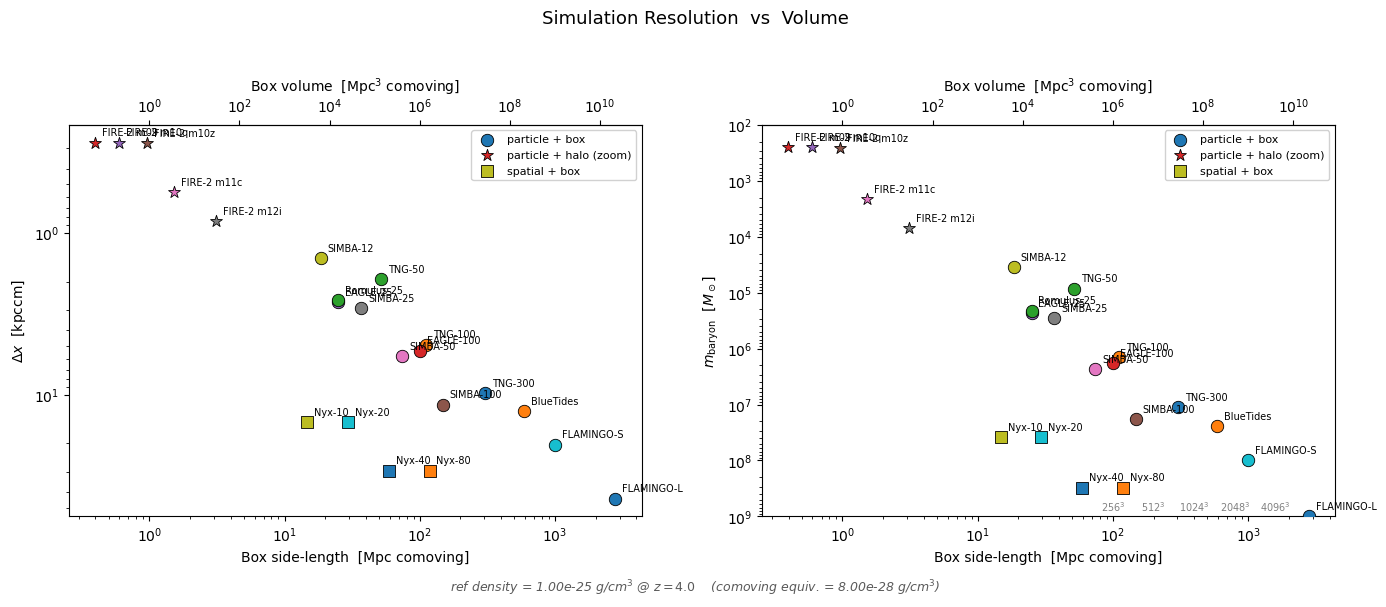

In [10]:
# --- Plot with the default (per-sim) ref densities -----------------
fig, axes = plot_simulation_comparison(sims,  savefig="sim_comparison_Qual.png")


Saved -> sim_comparison_overdense.png


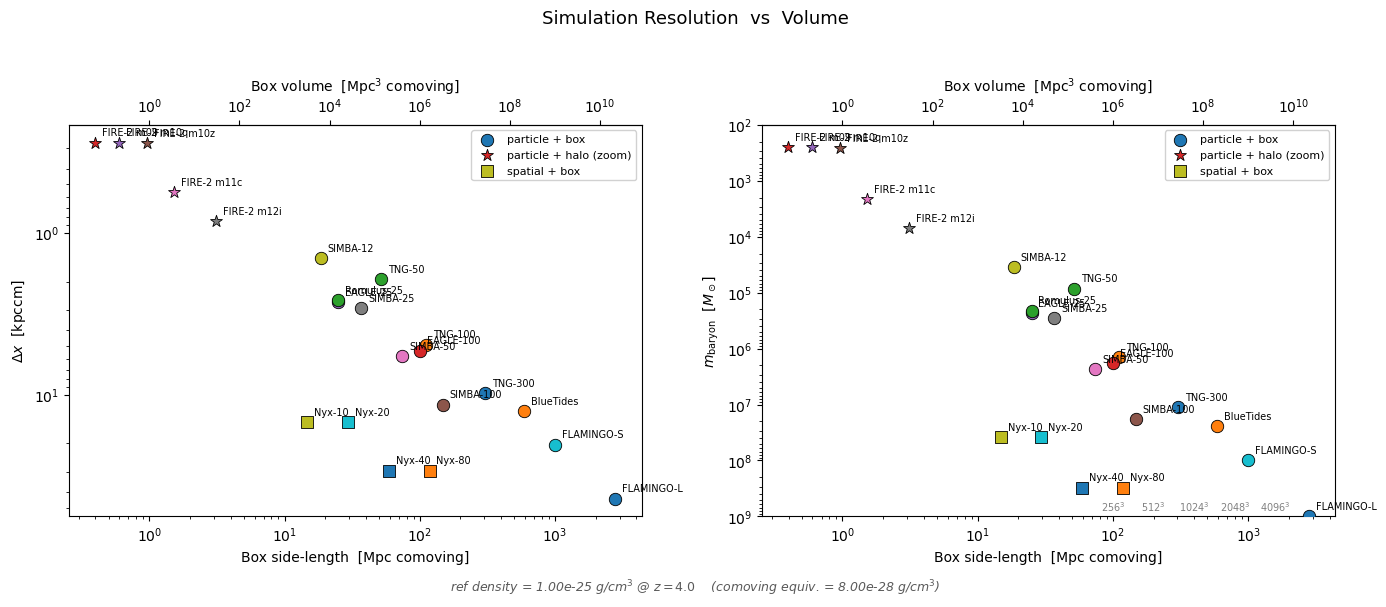

In [11]:

#--- Or override everyone to a common ref density ------------------
fig, axes = plot_simulation_comparison(sims,
               ref_density_cgs= 1e-25,
                   ref_redshift=4,
               savefig="sim_comparison_overdense.png")

Reference density (mean baryon): 4.190e-31 g/cm^3

SimulationInfo('TNG-300')
  m_baryon     = 1.100e+07 Msun
  dx           = 121.130 kpccm
  Volume       = 2.772e+07 Mpc^3
  Side-length  = 302.63 Mpc

SimulationInfo('TNG-100')
  m_baryon     = 1.400e+06 Msun
  dx           = 60.930 kpccm
  Volume       = 1.357e+06 Mpc^3
  Side-length  = 110.72 Mpc

SimulationInfo('EAGLE-100')
  m_baryon     = 1.810e+06 Msun
  dx           = 66.377 kpccm
  Volume       = 3.217e+06 Mpc^3
  Side-length  = 147.62 Mpc

SimulationInfo('FIRE-2 m12i')
  m_baryon     = 7.100e+03 Msun
  dx           = 10.468 kpccm
  Volume       = 3.064e+01 Mpc^3
  Side-length  = 3.13 Mpc

SimulationInfo('Grid sim')
  m_baryon     = 1.991e+04 Msun
  dx           = 14.762 kpccm
  Volume       = 4.021e+05 Mpc^3
  Side-length  = 73.81 Mpc

SimulationInfo('Grid zoom')
  m_baryon     = 4.951e+01 Msun
  dx           = 2.000 kpccm
  Volume       = 1.277e+01 Mpc^3
  Side-length  = 2.34 Mpc

Saved -> sim_comparison.png


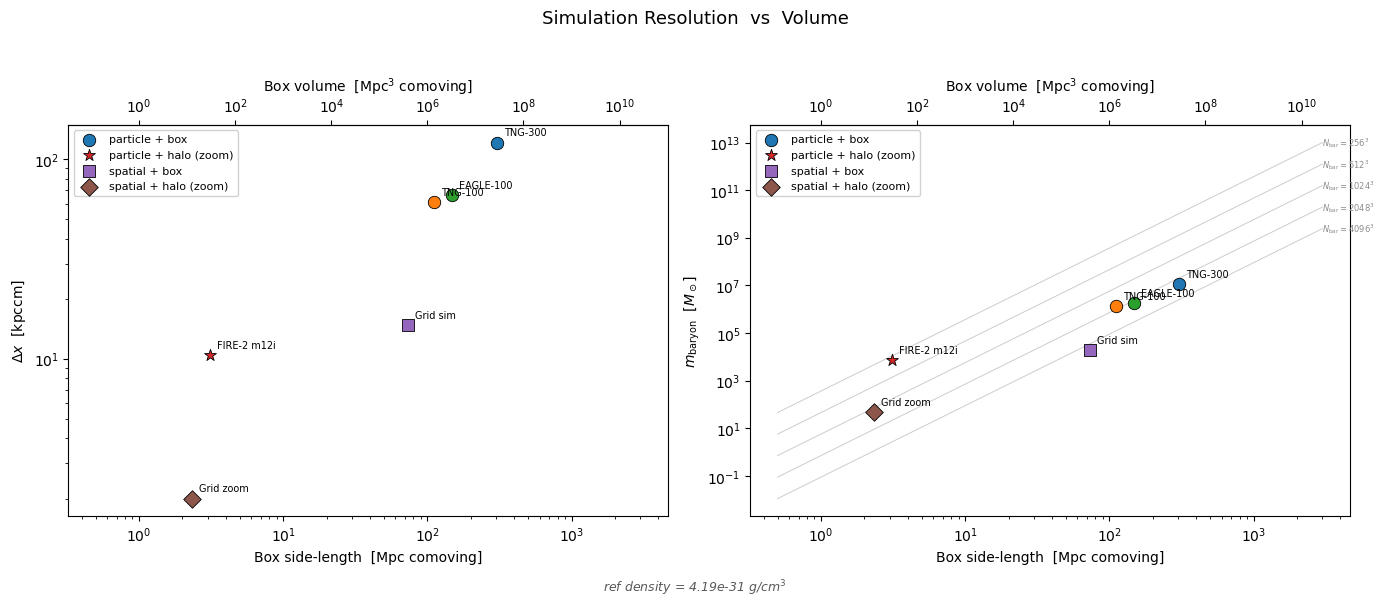

In [5]:
"""
simulation_info.py

A class to store and inter-convert resolution and volume information
for cosmological simulations, enabling apples-to-apples comparisons
between different flagship runs.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ---------------------------------------------------------------------------
# Default cosmology (Planck 2018-ish)
# ---------------------------------------------------------------------------
DEFAULT_COSMO = dict(
    h       = 0.6774,
    Omega_b = 0.0486,
    Omega_dm= 0.2589,
    # Omega_m is derived
    rho_crit_cgs = 1.8788e-29,  # h^2 g/cm^3  (i.e. rho_crit = rho_crit_cgs * h^2)
)
DEFAULT_COSMO["Omega_m"] = DEFAULT_COSMO["Omega_b"] + DEFAULT_COSMO["Omega_dm"]

# ---------------------------------------------------------------------------
# Unit conversion constants
# ---------------------------------------------------------------------------
MSUN_CGS   = 1.989e33        # g
MPC_CGS    = 3.0857e24       # cm
KPC_CGS    = MPC_CGS * 1e-3  # cm


class SimulationInfo:
    """
    Store and inter-convert two fundamental simulation properties:

      1. Resolution  -- either a baryonic particle mass (Msun) or a
         comoving spatial cell size (kpc, with optional /h).
      2. Volume      -- either a box side-length, a box volume, or a
         halo mass (zoom simulations).

    Parameters
    ----------
    name : str
        Human-readable label (e.g. "IllustrisTNG-300").

    resolution : tuple  (value, kind)
        value : float or str   -- numeric resolution value
        kind  : str            -- one of
            'particle'   ->  value is baryonic particle mass in Msun
            'kpccm/h'    ->  comoving spatial resolution in kpc/h
            'kpccm'      ->  comoving spatial resolution in kpc

    volume : tuple  (tag, value, unit)
        tag   : str   -- 'V' (volume), 'S' (side-length), or 'H' (halo)
        value : float -- numeric value
        unit  : str   -- for V/S: 'Mpccm/h' or 'Mpccm'
                         for H: 'M_dm', 'M_b', or 'M_tot'  (Msun implied)

    ref_density_cgs : float
        Reference density in g/cm^3 used to convert between particle mass
        and spatial resolution:  m_particle = rho_ref * (dx)^3.

    cosmo : dict, optional
        Cosmological parameters; defaults to Planck 2018.
    """

    def __init__(self, name, resolution, volume, ref_density_cgs,
                 cosmo=None):
        self.name = name
        self.cosmo = cosmo if cosmo is not None else dict(DEFAULT_COSMO)

        # Store the raw input tuples so we know what was specified
        self._resolution_input = resolution
        self._volume_input     = volume

        # Classify the input types for marker styling
        #   res_type:  'particle' or 'spatial'
        #   vol_type:  'box' or 'halo'
        res_kind = resolution[1]
        self.res_type = "particle" if res_kind == "particle" else "spatial"
        self.vol_type = "halo" if volume[0] == "H" else "box"

        # Compute everything from the raw inputs + reference density
        self.ref_density_cgs = ref_density_cgs
        self._compute(resolution, volume)

    # -------------------------------------------------------------------
    #  Core computation (called on init and when ref_density changes)
    # -------------------------------------------------------------------
    def _compute(self, resolution, volume):
        h  = self.cosmo["h"]
        Ob = self.cosmo["Omega_b"]
        Od = self.cosmo["Omega_dm"]
        Om = self.cosmo["Omega_m"]
        rho_crit = self.cosmo["rho_crit_cgs"] * h**2  # g/cm^3

        # ---------------------------------------------------------------
        # 1.  RESOLUTION  ->  particle mass (Msun)  +  spatial res (kpccm)
        # ---------------------------------------------------------------
        res_val  = float(resolution[0])
        res_kind = resolution[1]

        if res_kind == "particle":
            self.m_baryon_msun = res_val
            m_cgs = res_val * MSUN_CGS
            dx_cm = (m_cgs / self.ref_density_cgs) ** (1.0 / 3.0)
            self.dx_kpccm = dx_cm / KPC_CGS

        elif res_kind == "kpccm/h":
            dx_kpc = res_val / h
            self.dx_kpccm = dx_kpc
            dx_cm = dx_kpc * KPC_CGS
            m_cgs = self.ref_density_cgs * dx_cm**3
            self.m_baryon_msun = m_cgs / MSUN_CGS

        elif res_kind == "kpccm":
            self.dx_kpccm = res_val
            dx_cm = res_val * KPC_CGS
            m_cgs = self.ref_density_cgs * dx_cm**3
            self.m_baryon_msun = m_cgs / MSUN_CGS

        else:
            raise ValueError(f"Unknown resolution kind: {res_kind!r}")

        # ---------------------------------------------------------------
        # 2.  VOLUME  ->  comoving volume in Mpc^3
        # ---------------------------------------------------------------
        tag    = volume[0]
        v_val  = float(volume[1])
        v_unit = volume[2]

        if tag == "V":
            if v_unit == "Mpccm/h":
                self.volume_mpc3 = v_val / h**3
            elif v_unit == "Mpccm":
                self.volume_mpc3 = v_val
            else:
                raise ValueError(f"Unknown volume unit: {v_unit!r}")

        elif tag == "S":
            if v_unit == "Mpccm/h":
                side_mpc = v_val / h
            elif v_unit == "Mpccm":
                side_mpc = v_val
            else:
                raise ValueError(f"Unknown side-length unit: {v_unit!r}")
            self.volume_mpc3 = side_mpc**3

        elif tag == "H":
            m_halo_cgs = v_val * MSUN_CGS
            if v_unit == "M_dm":
                rho_mean_cgs = rho_crit * Od
            elif v_unit == "M_b":
                rho_mean_cgs = rho_crit * Ob
            elif v_unit == "M_tot":
                rho_mean_cgs = rho_crit * Om
            else:
                raise ValueError(f"Unknown halo mass type: {v_unit!r}")
            vol_cm3 = m_halo_cgs / rho_mean_cgs
            self.volume_mpc3 = vol_cm3 / MPC_CGS**3

        else:
            raise ValueError(f"Unknown volume tag: {tag!r}")

        # Derived convenience quantities
        self.side_mpc = self.volume_mpc3 ** (1.0 / 3.0)

    # -------------------------------------------------------------------
    #  Change reference density and recompute derived resolution
    # -------------------------------------------------------------------
    def set_ref_density(self, ref_density_cgs):
        """
        Update the reference density (g/cm^3) and recompute the
        particle-mass <-> spatial-resolution mapping.

        The volume side is *not* affected by reference density.
        """
        self.ref_density_cgs = ref_density_cgs
        self._compute(self._resolution_input, self._volume_input)

    # -------------------------------------------------------------------
    # Pretty printing
    # -------------------------------------------------------------------
    def __repr__(self):
        return (
            f"SimulationInfo('{self.name}')\n"
            f"  m_baryon     = {self.m_baryon_msun:.3e} Msun\n"
            f"  dx           = {self.dx_kpccm:.3f} kpccm\n"
            f"  Volume       = {self.volume_mpc3:.3e} Mpc^3\n"
            f"  Side-length  = {self.side_mpc:.2f} Mpc"
        )

    def summary_dict(self):
        """Return a dict handy for tabulation / plotting."""
        return dict(
            name          = self.name,
            m_baryon_msun = self.m_baryon_msun,
            dx_kpccm      = self.dx_kpccm,
            volume_mpc3   = self.volume_mpc3,
            side_mpc      = self.side_mpc,
            res_type      = self.res_type,
            vol_type      = self.vol_type,
        )


# =======================================================================
#  Marker style map for the 4 input-type categories
# =======================================================================
_MARKER_STYLES = {
    # (res_type, vol_type) : (marker, label)
    ("particle", "box")  : ("o",  "particle + box"),
    ("particle", "halo") : ("*",  "particle + halo (zoom)"),
    ("spatial",  "box")  : ("s",  "spatial + box"),
    ("spatial",  "halo") : ("D",  "spatial + halo (zoom)"),
}


# =======================================================================
#  Plotting function
# =======================================================================
def plot_simulation_comparison(sims, ref_density_cgs=None,
                                savefig=None, figsize=(14, 6),
                                xlim=None, ylim_dx=None, ylim_mass=None,
                                n_type="baryon"):
    """
    Scatter-plot a list of SimulationInfo objects on two panels:

        Left  :  box side-length  vs  dx  (comoving kpc)
        Right :  box side-length  vs  m_baryon  (Msun)

    Both axes are log-scale.  An upper x-axis shows box volume.

    Grey reference lines on the mass panel show iso-N curves (constant
    number of particles):
        m = rho_ref * L^3 / N

    Parameters
    ----------
    sims : list of SimulationInfo
    ref_density_cgs : float, optional
        If given, every sim's reference density is temporarily set to
        this value before plotting so the comparison is self-consistent.
        Original densities are restored afterwards.
    savefig : str or None
        Path to save the figure (e.g. 'comparison.png').
    figsize : tuple
    xlim : tuple or None
        (xmin, xmax) for box side-length axis (Mpc), shared by both panels.
    ylim_dx : tuple or None
        (ymin, ymax) for the dx panel (kpccm).
    ylim_mass : tuple or None
        (ymin, ymax) for the baryon mass panel (Msun).
    n_type : str
        What the iso-N reference lines represent:
        'baryon' -> N is the number of baryon particles (default).
        'total'  -> N is the total particle count (baryon + DM);
                    the baryon count is then N * Omega_b/Omega_m.
    """
    # --- optionally override reference densities -----------------------
    old_densities = None
    if ref_density_cgs is not None:
        old_densities = [s.ref_density_cgs for s in sims]
        for s in sims:
            s.set_ref_density(ref_density_cgs)
    # use whatever density is current (either overridden or original)
    active_density = sims[0].ref_density_cgs if sims else ref_density_cgs

    # --- gather data ---------------------------------------------------
    sides    = np.array([s.side_mpc for s in sims])
    volumes  = np.array([s.volume_mpc3 for s in sims])
    dx_arr   = np.array([s.dx_kpccm for s in sims])
    mass_arr = np.array([s.m_baryon_msun for s in sims])
    names    = [s.name for s in sims]
    cats     = [(s.res_type, s.vol_type) for s in sims]

    # --- figure --------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize,
                                   sharex=True)

    # ===================================================================
    #  Reference iso-N lines  (mass panel only)
    #
    #  m_baryon = rho_baryon_mean * L^3 / N_baryon
    #
    #  If n_type='baryon', the label N is N_baryon directly.
    #  If n_type='total',  N is total particles and
    #     N_baryon = N * (Omega_b / Omega_m).
    # ===================================================================
    cosmo = sims[0].cosmo if sims else DEFAULT_COSMO
    f_baryon = cosmo["Omega_b"] / cosmo["Omega_m"]   # ~0.158

    L_range = np.logspace(np.log10(0.5), np.log10(3000), 200)  # Mpc

    for n_per_side in [256, 512, 1024, 2048, 4096]:
        N_label = n_per_side**3       # what the label shows

        if n_type == "total":
            N_baryon = N_label * f_baryon
        else:
            N_baryon = N_label

        # m_baryon = rho_ref * L^3 / N_baryon   (all in cgs, then -> Msun)
        L_cm    = L_range * MPC_CGS
        m_line  = active_density * L_cm**3 / N_baryon / MSUN_CGS

        if n_type == "total":
            label_str = f"$N_{{\\rm tot}}={n_per_side}^3$"
        else:
            label_str = f"$N_{{\\rm bar}}={n_per_side}^3$"

        ax2.plot(L_range, m_line, color="0.80", lw=0.7, zorder=0)
        ax2.annotate(label_str,
                     xy=(L_range[-1], m_line[-1]),
                     fontsize=6, color="0.55", va="center",
                     annotation_clip=True)

    # ===================================================================
    #  Scatter points  (4 categories)
    # ===================================================================
    plotted_labels = set()
    for i, s in enumerate(sims):
        cat = cats[i]
        marker, cat_label = _MARKER_STYLES[cat]
        # only add legend entry once per category
        lbl = cat_label if cat_label not in plotted_labels else None
        plotted_labels.add(cat_label)

        kw = dict(marker=marker, s=80, edgecolors="k", linewidths=0.6,
                  zorder=5, label=lbl)
        ax1.scatter(sides[i], dx_arr[i],   **kw)
        ax2.scatter(sides[i], mass_arr[i], **kw)

        # annotate with name
        for ax, yval in [(ax1, dx_arr[i]), (ax2, mass_arr[i])]:
            ax.annotate(names[i], (sides[i], yval),
                        textcoords="offset points", xytext=(5, 5),
                        fontsize=7, zorder=6)

    # ===================================================================
    #  Axes formatting
    # ===================================================================
    for ax in (ax1, ax2):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Box side-length  [Mpc comoving]")
        ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
        #ax.grid(True, which="both", ls=":", lw=0.4, alpha=0.4)

        # --- upper x-axis: volume ---
        ax_top = ax.secondary_xaxis("top",
                                    functions=(lambda x: x**3,
                                               lambda v: v**(1./3.)))
        ax_top.set_xlabel("Box volume  [Mpc$^3$ comoving]")
        ax_top.set_xscale("log")

    ax1.set_ylabel(r"$\Delta x$  [kpccm]")
    ax2.set_ylabel(r"$m_{\rm baryon}$  [$M_\odot$]")

    # --- optional axis limits ------------------------------------------
    if xlim is not None:
        ax1.set_xlim(xlim)
        ax2.set_xlim(xlim)
    if ylim_dx is not None:
        ax1.set_ylim(ylim_dx)
    if ylim_mass is not None:
        ax2.set_ylim(ylim_mass)

    # --- reference density annotation ----------------------------------
    rho_str = f"ref density = {active_density:.2e} g/cm$^3$"
    fig.text(0.5, 0.01, rho_str, ha="center", fontsize=9,
             fontstyle="italic", color="0.35")

    fig.suptitle("Simulation Resolution  vs  Volume", fontsize=13, y=0.98)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if savefig:
        fig.savefig(savefig, dpi=200, bbox_inches="tight")
        print(f"Saved -> {savefig}")

    # --- restore original densities if we overrode them ----------------
    if old_densities is not None:
        for s, rho_old in zip(sims, old_densities):
            s.set_ref_density(rho_old)

    return fig, (ax1, ax2)


# =======================================================================
#  Quick demo / sanity check
# =======================================================================
if __name__ == "__main__":

    # Mean baryon density of the universe as a plausible reference density
    h  = DEFAULT_COSMO["h"]
    Ob = DEFAULT_COSMO["Omega_b"]
    rho_crit = DEFAULT_COSMO["rho_crit_cgs"] * h**2
    rho_bar  = rho_crit * Ob          # ~ 4.2e-31 g/cm^3

    print(f"Reference density (mean baryon): {rho_bar:.3e} g/cm^3\n")

    # --- Example sims (one from each input category) ---
    sims = [
        SimulationInfo(
            "TNG-300",
            resolution=("1.1e7", "particle"),
            volume=("S", 205, "Mpccm/h"),
            ref_density_cgs=rho_bar,
        ),
        SimulationInfo(
            "TNG-100",
            resolution=("1.4e6", "particle"),
            volume=("S", 75, "Mpccm/h"),
            ref_density_cgs=rho_bar,
        ),
        SimulationInfo(
            "EAGLE-100",
            resolution=("1.81e6", "particle"),
            volume=("S", 100, "Mpccm/h"),
            ref_density_cgs=rho_bar,
        ),
        SimulationInfo(
            "FIRE-2 m12i",
            resolution=("7100", "particle"),
            volume=("H", 1.2e12, "M_tot"),
            ref_density_cgs=rho_bar,
        ),
        SimulationInfo(
            "Grid sim",
            resolution=("10", "kpccm/h"),
            volume=("S", 50, "Mpccm/h"),
            ref_density_cgs=rho_bar,
        ),
        SimulationInfo(
            "Grid zoom",
            resolution=("2", "kpccm"),
            volume=("H", 5e11, "M_tot"),
            ref_density_cgs=rho_bar,
        ),
    ]

    for s in sims:
        print(s)
        print()

    # --- Plot with the default (per-sim) ref densities -----------------
    fig, axes = plot_simulation_comparison(sims,
                                           savefig="sim_comparison.png")

    # --- Or override everyone to a common ref density ------------------
    # fig, axes = plot_simulation_comparison(sims,
    #                ref_density_cgs=rho_bar * 100,
    #                savefig="sim_comparison_overdense.png")